## Ejercicio Python 1: Construcción de un portafolio eficiente con simulación

Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

**1. Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.**

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
tickers = ["BABA", "WIX", "DIS"]

prices = yf.download(tickers, start="2021-01-01")["Close"]
prices

[*********************100%***********************]  3 of 3 completed


Ticker,BABA,DIS,WIX
Date,,,
2021-01-04,216.388016,173.592010,253.149994
2021-01-05,228.306671,174.334534,259.250000
2021-01-06,216.160080,174.998871,247.860001
2021-01-07,215.485794,174.471313,252.479996
2021-01-08,224.308456,174.578781,263.529999
...,...,...,...
2026-02-24,153.110001,106.050003,65.489998
2026-02-25,152.279999,105.050003,65.610001
2026-02-26,148.050003,105.550003,71.309998


**2. Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.**

In [5]:
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
mean_returns * 100

Ticker
BABA    0.017513
DIS    -0.022549
WIX    -0.031464
dtype: float64

In [7]:
cov_matrix = returns.cov()
cov_matrix

Ticker,BABA,DIS,WIX
Ticker,,,
BABA,0.001025,0.000132,0.000352
DIS,0.000132,0.000341,0.000219
WIX,0.000352,0.000219,0.001271


**4. Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.***

Para cada portafolio, calcula:

Rendimiento esperado.

Riesgo (desviación estándar).

Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

In [8]:
n = 10000
rf = 0.04

p_returns = np.zeros(n)
p_volatilities = np.zeros(n)
p_sharpes = np.zeros(n)
all_weights = np.zeros((n, len(tickers)))

for i in range(n):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    all_weights[i, :] = weights
    
    port_return = np.sum(weights * mean_returns)
    
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe_ratio = (port_return - rf) / port_volatility
    
    p_returns[i] = port_return
    p_volatilities[i] = port_volatility
    p_sharpes[i] = sharpe_ratio

In [11]:
min_vol_idx = np.argmin(p_volatilities)
max_ret_idx = np.argmax(p_returns)
max_sharpe_idx = np.argmax(p_sharpes)

print("Mejor Sharpe: Rendimiento=" + str(round(p_returns[max_sharpe_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[max_sharpe_idx], 4)))
print("Menor Riesgo: Rendimiento=" + str(round(p_returns[min_vol_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[min_vol_idx], 4)))
print("Mayor Rendimiento: Rendimiento=" + str(round(p_returns[max_ret_idx], 4)) + ", Riesgo=" + str(round(p_volatilities[max_ret_idx], 4)))

Mejor Sharpe: Rendimiento=-0.0003, Riesgo=0.035
Menor Riesgo: Rendimiento=-0.0002, Riesgo=0.0173
Mayor Rendimiento: Rendimiento=0.0002, Riesgo=0.0311


Notemos que este es un portafolio extraño, con rendimientos usualmente negativos, por eso, el portafolio de mayor rendimiento tiene un retorno positivo (0.0002) y un riesgo (0.0311) que es menor al del portafolio de mejor sharpe (retorno de -0.0003 y riesgo de 0.035), esto suele suceder cuando el rendimiento del portafolio es menor a la tasa libre de riesgo.

**5. Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:**

Identifica el portafolio de menor riesgo.

Identifica el portafolio de mayor rendimiento.

Identifica el portafolio con mayor Sharpe.

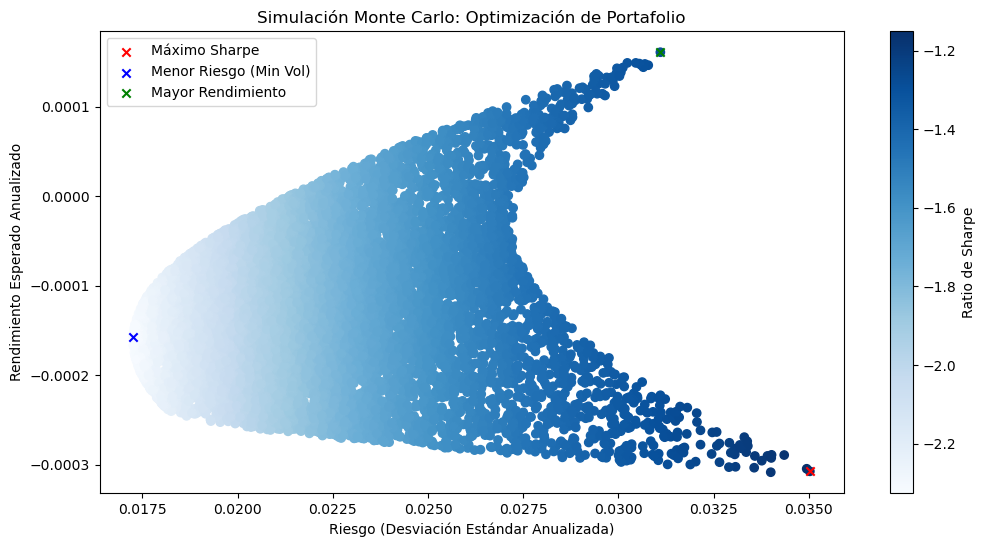

In [17]:
plt.figure(figsize=(12, 6))

plt.scatter(p_volatilities, p_returns, c=p_sharpes, cmap='Blues', marker='o')
plt.colorbar(label='Ratio de Sharpe')

plt.scatter(p_volatilities[max_sharpe_idx], p_returns[max_sharpe_idx], marker='x', color='r', label='Máximo Sharpe')

plt.scatter(p_volatilities[min_vol_idx], p_returns[min_vol_idx], marker='x', color='b', label='Menor Riesgo (Min Vol)')

plt.scatter(p_volatilities[max_ret_idx], p_returns[max_ret_idx], marker='x', color='g', label='Mayor Rendimiento')

plt.title('Simulación Monte Carlo: Optimización de Portafolio')
plt.xlabel('Riesgo (Desviación Estándar Anualizada)')
plt.ylabel('Rendimiento Esperado Anualizado')
plt.legend()
plt.show()

**6. Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.**

Breve Análisis del Portafolio

Los resultados de la simulación muestran rendimientos esperados sumamente bajos, siendo negativos en dos de los tres portafolios destacados.

Para este caso particular, la recomendación lógica es el portafolio de Mayor Rendimiento porque es la única opción de las tres que ofrece una esperanza de rendimiento positiva. Además, es en realidad es superior al portafolio de Mejor Sharpe porque te entrega un mejor rendimiento asumiendo un riesgo menor.

Si el inversionista tiene una aversión al riesgo extrema, la segunda opción válida sería el portafolio de Menor Riesgo, donde se acepta una expectativa de rendimiento ligeramente negativa (-0.0002) a cambio de reducir drásticamente la volatilidad a casi la mitad (0.0173).